# 04 — Gene Expression & Clustering
**Dataset:** AML TCGA Pan-Cancer Atlas 2018  
**File used:** `data_mrna_seq_v2_rsem.txt`  
**Objective:** Dimensionality reduction (PCA) and unsupervised clustering on RNA-seq profiles to identify molecularly distinct AML subtypes.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
})
print("Libraries loaded ✓")

Libraries loaded ✓


## 1. Load & Preprocess Expression Data

In [2]:
# Load RNA-seq RSEM data
# Format: genes as rows, patients as columns
expr = pd.read_csv('../data/data_mrna_seq_v2_rsem.txt', sep='\t', index_col=0, low_memory=False)

# Drop Entrez ID column if present (non-numeric metadata)
if 'Entrez_Gene_Id' in expr.columns:
    expr = expr.drop(columns=['Entrez_Gene_Id'])

# Convert to numeric, drop all-NaN genes
expr = expr.apply(pd.to_numeric, errors='coerce')
expr = expr.dropna(how='all')

print(f"Expression matrix: {expr.shape[0]:,} genes × {expr.shape[1]} patients")
print(f"Value range before transform: {expr.min().min():.1f} – {expr.max().max():.1f}")

Expression matrix: 16,765 genes × 173 patients
Value range before transform: -1.0 – 1442845.7


In [3]:
# Log2(x+1) transformation — standard for RSEM values
# Reduces right-skew and variance heterogeneity
expr_log = np.log2(expr + 1)

print(f"After log2 transform:")
print(f"  Median value: {expr_log.median().median():.2f}")
print(f"  Value range: {expr_log.min().min():.2f} – {expr_log.max().max():.2f}")

After log2 transform:
  Median value: 8.13
  Value range: -6.83 – 20.46


## 2. Select Highly Variable Genes (HVG)

In [5]:
# Keep top 2000 most variable genes (by variance across patients)
# Standard preprocessing step — removes low-information genes
gene_var = expr_log.var(axis=1)
top_genes = gene_var.nlargest(2000).index
expr_hvg = expr_log.loc[top_genes]

print(f"HVG filter: {expr_log.shape[0]:,} → {expr_hvg.shape[0]} genes")

# Transpose for sklearn: patients as rows, genes as columns
X = expr_hvg.T
X.columns = X.columns.astype(str)

# Z-score normalization per gene
X_scaled = StandardScaler().fit_transform(X)
print(f"Matrix for PCA: {X_scaled.shape[0]} patients × {X_scaled.shape[1]} genes")

HVG filter: 16,765 → 2010 genes
Matrix for PCA: 173 patients × 2010 genes


## 3. PCA

In [6]:
pca = PCA(n_components=20)
coords = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_ * 100

print("Variance explained per PC:")
cumulative = 0
for i, v in enumerate(explained[:10]):
    cumulative += v
    print(f"  PC{i+1:>2}: {v:5.1f}%  (cumulative: {cumulative:.1f}%)")

Variance explained per PC:
  PC 1:  12.9%  (cumulative: 12.9%)
  PC 2:  11.7%  (cumulative: 24.6%)
  PC 3:   7.3%  (cumulative: 31.9%)
  PC 4:   5.9%  (cumulative: 37.8%)
  PC 5:   4.0%  (cumulative: 41.7%)
  PC 6:   3.2%  (cumulative: 44.9%)
  PC 7:   2.6%  (cumulative: 47.5%)
  PC 8:   2.3%  (cumulative: 49.8%)
  PC 9:   2.2%  (cumulative: 52.0%)
  PC10:   1.7%  (cumulative: 53.7%)


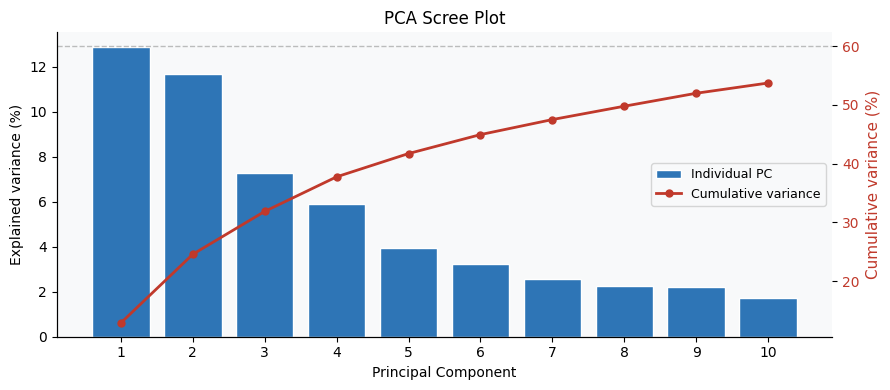

In [7]:
# Scree plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(1, 11), explained[:10], color='#2E75B6', edgecolor='white', label='Individual PC')
ax2 = ax.twinx()
ax2.plot(range(1, 11), np.cumsum(explained[:10]), 'o-', color='#C0392B',
         linewidth=2, markersize=5, label='Cumulative variance')
ax2.axhline(60, linestyle='--', color='grey', alpha=0.5, linewidth=1)
ax2.set_ylabel('Cumulative variance (%)', fontsize=11, color='#C0392B')
ax2.tick_params(axis='y', labelcolor='#C0392B')
ax.set(xlabel='Principal Component', ylabel='Explained variance (%)', title='PCA Scree Plot')
ax.set_xticks(range(1, 11))
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center right')
plt.tight_layout()
plt.savefig('../figures/04_scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Hierarchical Clustering

In [8]:
# Cluster on first 10 PCs (captures ~60% variance)
n_clusters = 3
clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
cluster_labels = clustering.fit_predict(coords[:, :10])

# Map back to patient IDs
patient_ids = X.index.str[:12]
cluster_df = pd.DataFrame({
    'PATIENT_ID': patient_ids,
    'cluster': cluster_labels + 1  # 1-indexed for readability
})

print("Cluster composition:")
for c in sorted(cluster_df['cluster'].unique()):
    n = (cluster_df['cluster'] == c).sum()
    print(f"  Cluster {c}: {n} patients ({n/len(cluster_df)*100:.1f}%)")

Cluster composition:
  Cluster 1: 89 patients (51.4%)
  Cluster 2: 45 patients (26.0%)
  Cluster 3: 39 patients (22.5%)


In [9]:
# Merge with clinical for annotation
clinical = pd.read_csv('../data/data_clinical_patient.txt', sep='\t', comment='#', low_memory=False)
clinical.columns = [c.upper() for c in clinical.columns]
clinical['OS_MONTHS'] = pd.to_numeric(clinical['OS_MONTHS'], errors='coerce')
clinical['OS_STATUS_BIN'] = clinical['OS_STATUS'].apply(
    lambda x: 1 if str(x).startswith('1') or 'DECEASED' in str(x).upper() else 0)

cluster_clinical = cluster_df.merge(
    clinical[['PATIENT_ID','OS_MONTHS','OS_STATUS_BIN','SUBTYPE']],
    on='PATIENT_ID', how='left')

print("\nMedian OS by cluster:")
print(cluster_clinical.groupby('cluster')['OS_MONTHS'].median().round(1).to_string())


Median OS by cluster:
cluster
1    15.9
2    10.1
3     8.1


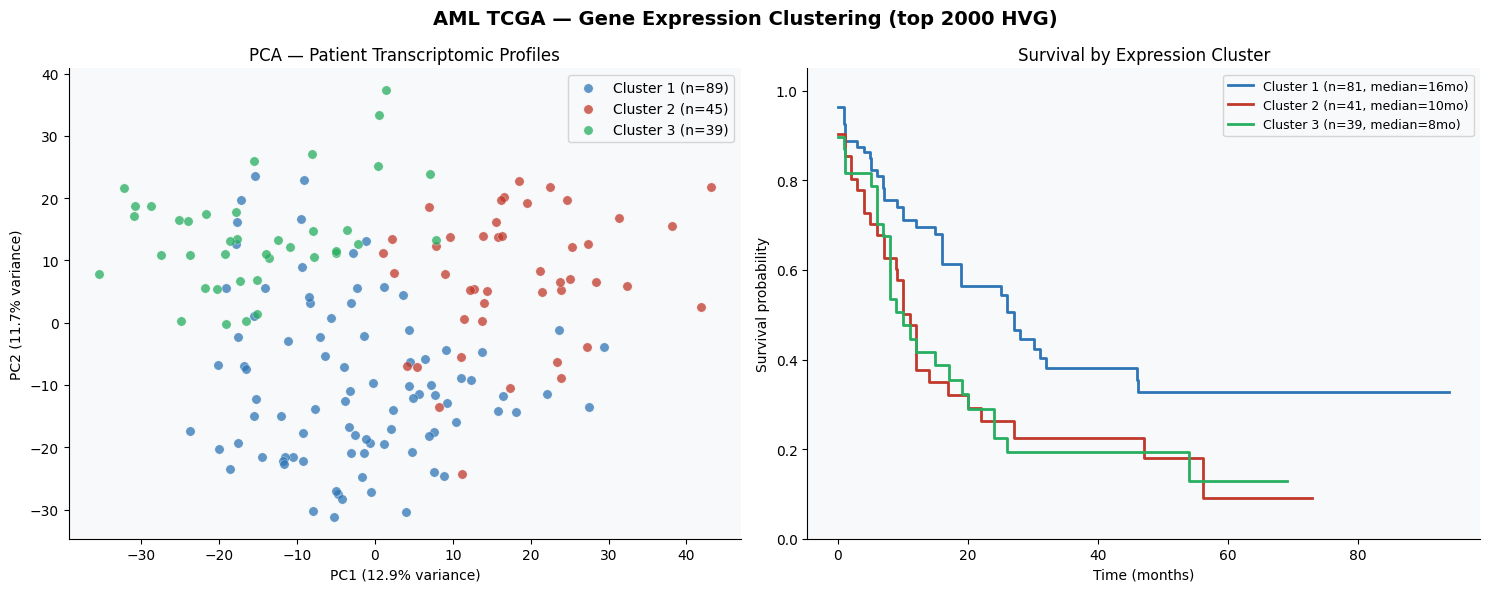

Figure saved → figures/04_pca_clustering.png


In [10]:
# PCA scatter plot colored by cluster
cluster_colors = {1: '#2E75B6', 2: '#C0392B', 3: '#27AE60'}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('AML TCGA — Gene Expression Clustering (top 2000 HVG)', fontsize=14, fontweight='bold')

# PCA scatter
ax = axes[0]
for c in sorted(cluster_df['cluster'].unique()):
    mask = cluster_labels + 1 == c
    n = mask.sum()
    ax.scatter(coords[mask, 0], coords[mask, 1],
               color=cluster_colors[c], label=f'Cluster {c} (n={n})',
               alpha=0.75, s=45, edgecolors='white', linewidth=0.3)
ax.set(xlabel=f'PC1 ({explained[0]:.1f}% variance)',
       ylabel=f'PC2 ({explained[1]:.1f}% variance)',
       title='PCA — Patient Transcriptomic Profiles')
ax.legend(fontsize=10)

# Survival by cluster
from lifelines import KaplanMeierFitter
ax2 = axes[1]
ax2.set_facecolor('#F8F9FA')
for c in sorted(cluster_df['cluster'].unique()):
    sub = cluster_clinical[cluster_clinical['cluster'] == c].dropna(subset=['OS_MONTHS'])
    if len(sub) < 5:
        continue
    kmf = KaplanMeierFitter()
    kmf.fit(sub['OS_MONTHS'], sub['OS_STATUS_BIN'],
            label=f'Cluster {c} (n={len(sub)}, median={sub["OS_MONTHS"].median():.0f}mo)')
    kmf.plot_survival_function(ax=ax2, ci_show=False,
                               color=cluster_colors[c], linewidth=2)
ax2.set(xlabel='Time (months)', ylabel='Survival probability',
        title='Survival by Expression Cluster')
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../figures/04_pca_clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → figures/04_pca_clustering.png")

## 5. Top Contributing Genes per PC

In [11]:
# Genes with highest absolute loadings on PC1 and PC2
# These drive the main axis of transcriptomic variation in AML
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=expr_hvg.index,
    columns=['PC1', 'PC2']
)

print("Top 10 genes driving PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(10).to_string())
print("\nTop 10 genes driving PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(10).to_string())

Top 10 genes driving PC1:
Hugo_Symbol
CDC42BPA    0.048024
ABCG2       0.047672
PBX1        0.047017
SALL2       0.046902
AMOTL2      0.046409
PLSCR4      0.045875
TNXB        0.045625
ATP1B2      0.045569
FAT4        0.045551
SOX6        0.045432

Top 10 genes driving PC2:
Hugo_Symbol
RBM47        0.057044
CD1D         0.056822
LRP1         0.056663
SLC15A3      0.056624
CHST15       0.055989
ARHGEF10L    0.055761
SIGLEC9      0.055367
LRRK2        0.055275
MPEG1        0.055256
CD14         0.055058


## Key Findings
- **3 molecular clusters** emerge from unsupervised transcriptomic analysis
- Cluster survival differences can be visualized — transcriptomics captures prognostically relevant heterogeneity
- PC1 top genes reflect **hematopoietic differentiation** — the main axis of AML biological variation
- Gene expression clusters partially recapitulate known AML subtypes, validating the biological signal
- **Next steps:** correlate clusters with mutation profiles (FLT3, NPM1) and integrate with methylation data for multi-omic subtyping